# Apple precio de las acciones

## Contexto:

Este conjunto de datos contiene información histórica diaria sobre las acciones de Apple Inc. durante el último año. Incluye precios de apertura, máximo, mínimo, cierre y cierre ajustado, además del volumen de negociación diario. Al estar estructurado como una serie temporal, resulta muy útil para analizar tendencias de precios, realizar estudios de series temporales y construir modelos predictivos sobre el comportamiento del mercado bursátil. Su formato numérico lo hace especialmente adecuado para técnicas de regresión y modelado estadístico.

In [1]:
# Librerias necesarias

# Datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

# Modelos de tiempo
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Estadisticos
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.metrics import r2_score
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import warnings
warnings.filterwarnings('ignore')


In [2]:
# Importar base de datos C:\Users\salasistemas.UTB\Desktop\TimeSeries\data\apple.csv
df = pd.read_csv(r'C:\Users\salasistemas.UTB\Desktop\TimeSeries\data\apple.csv', parse_dates=['Date'], index_col='Date')
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2023-11-02 00:00:00+00:00,176.665985,177.570007,177.779999,175.460007,175.520004,77334800
2023-11-03 00:00:00+00:00,175.750671,176.649994,176.820007,173.350006,174.240005,79763700
2023-11-06 00:00:00+00:00,178.317520,179.229996,179.429993,176.210007,176.380005,63841300
2023-11-07 00:00:00+00:00,180.894333,181.820007,182.440002,178.970001,179.179993,70530000
2023-11-08 00:00:00+00:00,181.958893,182.889999,183.449997,181.589996,182.350006,49340300


In [18]:
# Ver la cantidad de datos
print(f'Cantidad de datos: {len(df)}')
# Ver la información de la base de datos
print(df.info())

Cantidad de datos: 252
<class 'pandas.DataFrame'>
DatetimeIndex: 252 entries, 2023-11-02 00:00:00+00:00 to 2024-11-01 00:00:00+00:00
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  252 non-null    float64
 1   Close      252 non-null    float64
 2   High       252 non-null    float64
 3   Low        252 non-null    float64
 4   Open       252 non-null    float64
 5   Volume     252 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.8 KB
None


- Adj Close (Precio de Cierre Ajustado): Es el valor más crítico para el análisis estadístico. Modifica el precio de cierre para reflejar dividendos, divisiones de acciones (splits) y otras acciones corporativas, proporcionando una visión real de la rentabilidad.

- Close (Precio de Cierre): Representa el precio final al que se negoció el activo al terminar la jornada de trading. Es el precio estándar de mercado sin los ajustes por eventos corporativos.

- High (Máximo): Indica el nivel de precio más alto alcanzado por el activo durante el intervalo de tiempo específico (en este caso, diario). Refleja el punto máximo de presión de compra.

- Low (Mínimo): Registra el precio más bajo negociado en el día. Es un indicador clave para identificar niveles de soporte o suelos de mercado.

- Open (Precio de Apertura): Es el precio al que se ejecutó la primera transacción del día. La diferencia entre este y el cierre anterior suele indicar el sentimiento del mercado tras el cierre de la sesión previa.

- Volume (Volumen): Representa la cantidad total de unidades (acciones o contratos) negociadas. Un volumen alto valida la fuerza de una tendencia, mientras que un volumen bajo sugiere falta de convicción en el movimiento del precio.

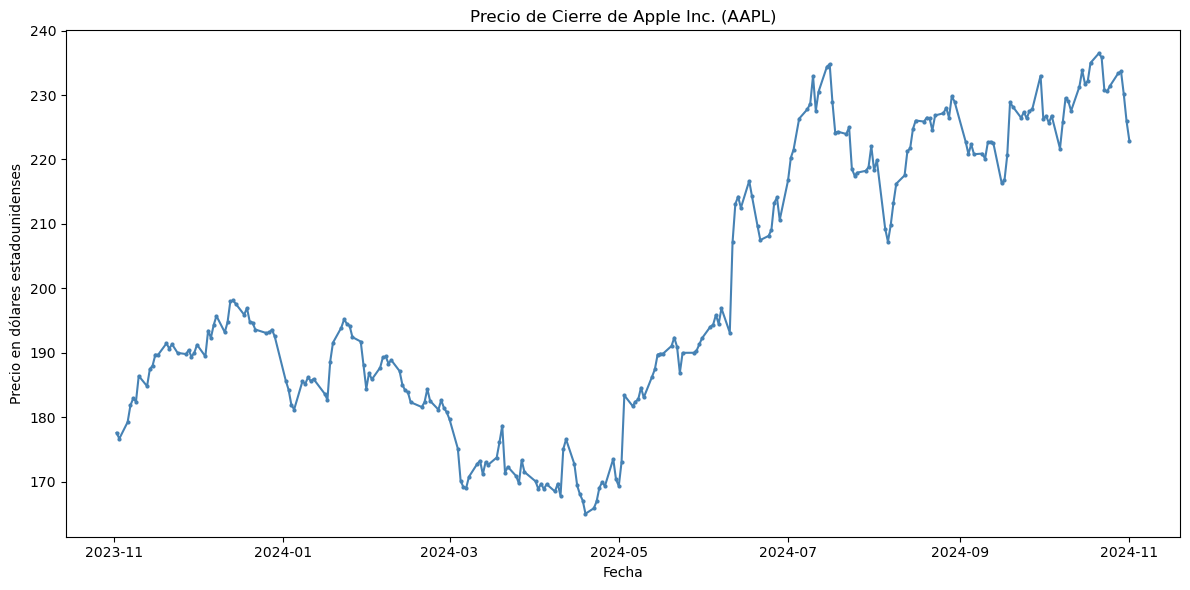

In [3]:
# Usar la columna de precio de cierre (Close) como serie principal
apple_close = df['Close']

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(df.index, apple_close, marker='o', markersize=2, color='steelblue')
ax.set_title('Precio de Cierre de Apple Inc. (AAPL)')
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio en dólares estadounidenses')
plt.tight_layout()
plt.show()

- Tendencia: Predomina un sesgo alcista a largo plazo, con una recuperación acelerada a partir de mayo tras un primer trimestre correctivo.

- Volatilidad: Se observa una dispersión significativa en los precios, con oscilaciones bruscas que indican periodos de alta sensibilidad al mercado.

- Soporte y Resistencia: El valor estableció un suelo estadístico cerca de los 165 USD y encontró un techo técnico en torno a los 235 USD.

- Rango de Operación: La amplitud del movimiento (rango) fue de aproximadamente 70 USD, lo que refleja un crecimiento sustancial de punta a punta.

## Verificar estacionaridad de la serie original

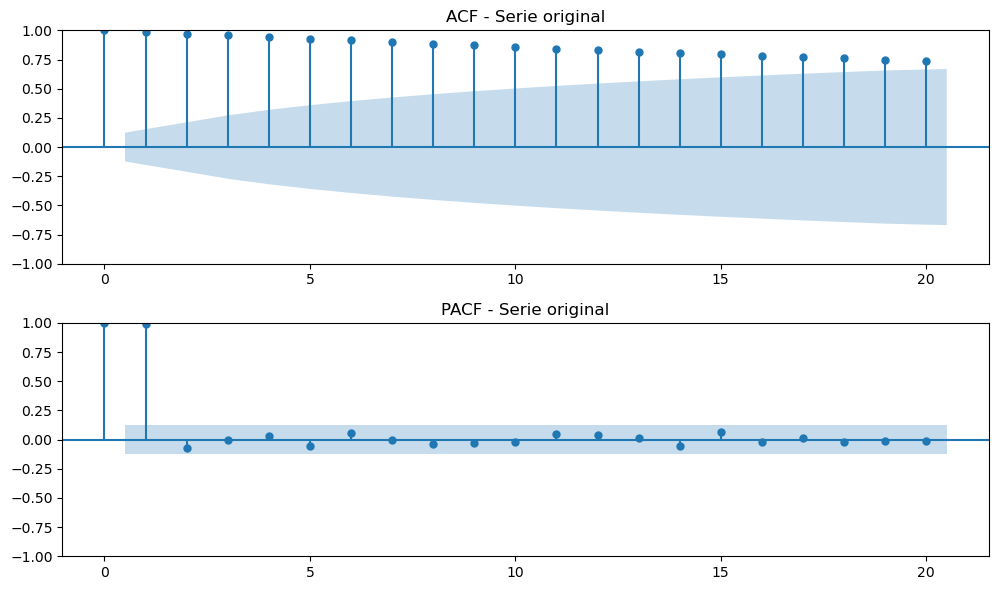

In [4]:
# Graficar la función de ACF y PACF
def graficar_autocorrelacion(data, title, maxlag=20):
    fig, axes = plt.subplots(2, 1, figsize=(10, 6))
    plot_acf(data, lags=maxlag, ax=axes[0], title=f'ACF - {title}')
    plot_pacf(data, lags=maxlag, ax=axes[1], title=f'PACF - {title}')
    plt.tight_layout()
    plt.show()

graficar_autocorrelacion(apple_close, title="Serie original")

- No estacionariedad: El decaimiento extremadamente lento y lineal en la ACF indica que la serie original no es estacionaria, lo que confirma la presencia de una tendencia marcada en los precios.

- Autocorrelación persistente: Casi todos los retardos (lags) en la ACF están fuera de la banda de confianza, lo que significa que los valores pasados tienen una influencia prolongada en los precios actuales.

- Predominancia del primer retardo: En la PACF, solo el primer lag es significativamente alto y cercano a 1, sugiriendo que la serie se comporta como un proceso de camino aleatorio (Random Walk).

- Efecto de "Corte" en PACF: El hecho de que la PACF caiga abruptamente a cero después del primer retardo es una señal clásica de que se requiere aplicar diferenciación para estabilizar la serie.

In [5]:
def test_autocorrelacion(datos, n_lags=20):
    # Ljung-Box (Prueba global)
    lb_test        = acorr_ljungbox(datos, lags=n_lags, return_df=True)
    min_p_value    = lb_test['lb_pvalue'].min()
    lb_stat        = lb_test.loc[lb_test['lb_pvalue'] == min_p_value, 'lb_stat'].iloc[0]

    # Durbin-Watson (Autocorrelación de primer orden)
    dw_stat = durbin_watson(datos)

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Durbin-Watson", f"Ljung-Box (hasta lag {n_lags})"],
        'Estadístico' : [round(dw_stat, 4), round(lb_stat, 4)],
        'P-valor'     : [None, round(min_p_value, 4)]
    })

    # Conclusiones
    dw_conclu = (
        "Sin autocorrelación" if 1.5 < dw_stat < 2.5 else
        "Autocorrelación positiva" if dw_stat < 1.5 else
        "Autocorrelación negativa"
    )
    lb_conclu = "Sin autocorrelación" if min_p_value > 0.05 else "Autocorrelación detectada"
    tab_test['Conclusión'] = [dw_conclu, lb_conclu]

    print("=" * 80)
    print("PRUEBA DE LJUNG-BOX Y DURBIN-WATSON")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)

test_autocorrelacion(apple_close.dropna(), n_lags=20)

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor                 Conclusión
0             Durbin-Watson       0.0002      NaN   Autocorrelación positiva
1  Ljung-Box (hasta lag 20)    1604.7572      0.0  Autocorrelación detectada


- Autocorrelación Serial Extrema: El estadístico de Durbin-Watson cercano a 0 confirma una fortísima autocorrelación positiva, indicando que los residuos no son independientes y mantienen una dependencia lineal casi perfecta.
- Invalidez de Ruido Blanco: El p-valor de 0.0 en la prueba de Ljung-Box permite rechazar la hipótesis nula de independencia, demostrando que la serie conserva estructura de información no capturada.
- Persistencia de Largo Plazo: El valor tan elevado del estadístico Ljung-Box ($1604.75$) refleja que la correlación se mantiene significativa a lo largo de los 20 retardos analizados.

In [6]:
def test_estacionariedad(datos):
    # Augmented Dickey-Fuller
    adf_result = adfuller(datos)
    # KPSS
    kpss_result = kpss(datos, regression='c')

    # Tabla de resultados
    tab_test = pd.DataFrame({
        'Test'        : ["Prueba Augmented Dickey-Fuller (ADF)", "Prueba KPSS"],
        'Estadístico' : [round(adf_result[0],  4), round(kpss_result[0],  4)],
        'P-valor'     : [round(adf_result[1], 4), round(kpss_result[1], 4)],
        "Estacionario" : ["Sí" if adf_result[1] < 0.05 else "No", "No" if kpss_result[1] < 0.05 else "Sí"]
    })

    print("=" * 80)
    print("PRUEBA DE ESTACIONARIEDAD")
    print("=" * 80)
    print(tab_test)
    print("=" * 80)


test_estacionariedad(apple_close.dropna())

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)      -1.0154   0.7476           No
1                           Prueba KPSS       1.6499   0.0100           No


- Presencia de Raíz Unitaria (ADF): El elevado p-valor (0.7476) impide rechazar la hipótesis nula de la prueba de Dickey-Fuller Aumentada. Esto confirma formalmente que la serie no revierte a una media constante y que sus fluctuaciones no se disipan con el tiempo.

- Ausencia de Estacionariedad en Tendencia (KPSS): A diferencia de la ADF, esta prueba asume la estacionariedad como hipótesis nula. El p-valor crítico (0.0100) nos obliga a rechazarla, ratificando que el precio está dominado por una tendencia estructural fuerte.

- Diagnóstico Conclusivo: La concordancia exacta de ambas pruebas —una fallando en probar estacionariedad y la otra rechazándola de plano— ofrece una certeza estadística de que la serie es "no estacionaria estricta".

- Implicación para el Modelado: Este resultado es el argumento matemático definitivo que justifica la necesidad de transformar los datos (aplicando una diferenciación de primer orden o calculando retornos logarítmicos) antes de intentar cualquier pronóstico predictivo.

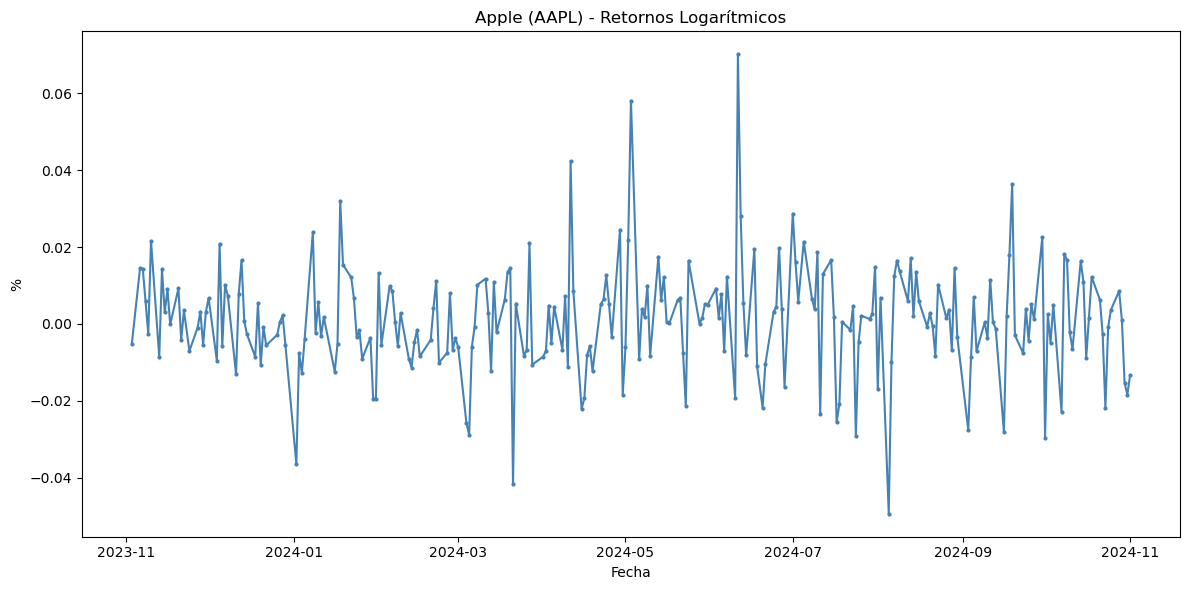

In [7]:
# Primera diferencia de la serie
apple_diff = apple_close.dropna().diff().dropna()

# Logaritmo y primera diferencia (tasas de crecimiento/retornos logarítmicos)
apple_log = np.log(apple_close.dropna())
apple_crecimiento = apple_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(apple_crecimiento, marker='o', markersize=2, color='steelblue')
ax.set_title('Apple (AAPL) - Retornos Logarítmicos')
ax.set_xlabel('Fecha')
ax.set_ylabel('%')
plt.tight_layout()
plt.show()

- Estacionariedad: La transformación estabilizó la media cerca de cero, eliminando la tendencia alcista y facilitando un análisis estadístico más riguroso.

- Reversión a la media: Se observa una oscilación constante alrededor del eje central, confirmando que los rendimientos tienden a equilibrarse tras cada movimiento.

- Agrupamiento de volatilidad: Los periodos de alta agitación se concentran en zonas específicas (como mayo y agosto), indicando fases transitorias de mayor riesgo.

- Presencia de Shocks: Los picos extremos reflejan eventos de alta sensibilidad o "colas pesadas", donde el activo experimentó cambios diarios muy superiores al promedio.

- Estructura de Ruido: La serie se asemeja ahora a un proceso estocástico independiente, ideal para aplicar modelos de pronóstico avanzados sin el sesgo del precio original.

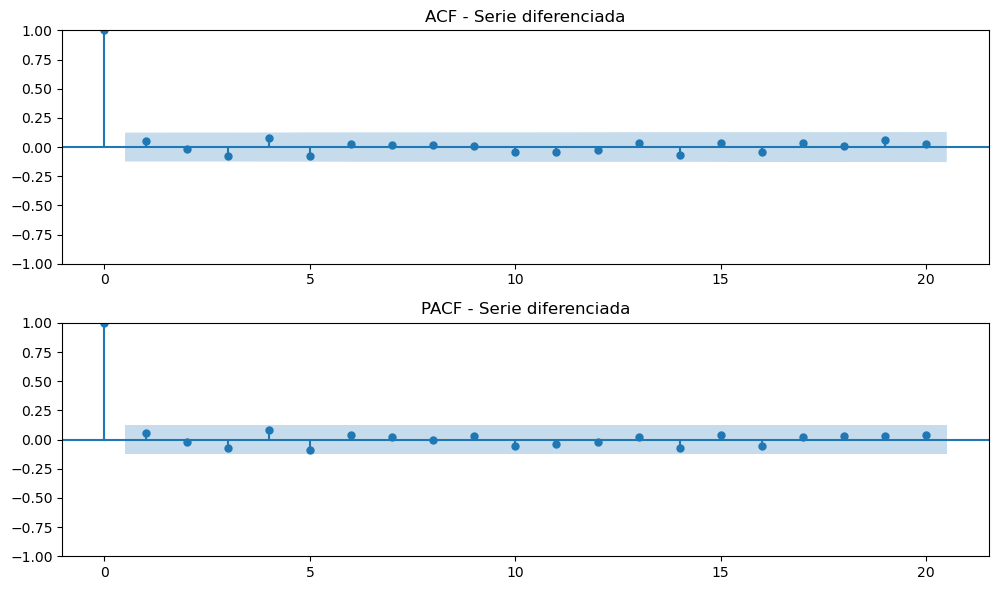

PRUEBA DE ESTACIONARIEDAD
                                   Test  Estadístico  P-valor Estacionario
0  Prueba Augmented Dickey-Fuller (ADF)     -14.9092      0.0           Sí
1                           Prueba KPSS       0.0976      0.1           Sí


In [8]:
# Graficar la función de ACF y PACF de la serie diferenciada
graficar_autocorrelacion(apple_diff, title="Serie diferenciada")

# Test estacionariedad
test_estacionariedad(apple_diff)

- Estructura de Ruido Blanco: La caída inmediata de prácticamente todos los retardos dentro de las bandas de confianza indica que la serie diferenciada se comporta como ruido blanco, careciendo de patrones predecibles.

- Independencia Estadística: Al no haber picos significativos fuera de la zona sombreada, se confirma que no existe una relación lineal entre los rendimientos de hoy y los de días anteriores.

- Validación de la Estacionariedad: Estas gráficas son la prueba definitiva de que la diferenciación eliminó con éxito la tendencia y la memoria de la serie original, estabilizándola por completo.

- Ausencia de Componentes AR/MA: La falta de picos claros en la ACF y PACF sugiere que la serie no requiere términos autorregresivos (AR) ni de media móvil (MA) adicionales para ser modelada.

- Confirmación de Caminata Aleatoria: El comportamiento observado refuerza la hipótesis de que los precios de Apple siguen un camino aleatorio, donde los cambios de precio son aleatorios e independientes.

## Estimación modelos ARIMA

In [9]:
from statsmodels.tsa.arima.model import ARIMA

# ARIMA(1, 0, 0) sobre los retornos logarítmicos
m_arima110 = ARIMA(apple_crecimiento, order=(1, 1, 0)).fit()
print(m_arima110.summary())

# Guardar modelos estimados
modelos = {}
modelos["ARIMA(1, 1, 0)"] = m_arima110

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 660.508
Date:                Sat, 11 Apr 2026   AIC                          -1317.016
Time:                        14:01:29   BIC                          -1309.973
Sample:                             0   HQIC                         -1314.181
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4672      0.048     -9.721      0.000      -0.561      -0.373
sigma2         0.0003   1.96e-05     15.123      0.000       0.000       0.000
Ljung-Box (L1) (Q):                   4.49   Jarque-

- Falta de Significancia Predictiva: Tanto la constante como el coeficiente autorregresivo (ar.L1) tienen p-valores superiores a $0.05$. Esto indica que, estadísticamente, el retorno de ayer no es un predictor lineal fiable para el retorno de hoy.
- Validación de Residuos (Ruido Blanco): El p-valor de Ljung-Box ($0.99$) es muy alto, lo que significa que no hay autocorrelación remanente en los errores. El modelo ha extraído toda la información lineal disponible en la serie.
- No Normalidad de los Errores: La prueba Jarque-Bera tiene un p-valor de $0.00$, rechazando la normalidad. La elevada curtosis ($6.50$) confirma la presencia de "colas pesadas", es decir, movimientos extremos más frecuentes que en una distribución normal.
- Persistencia de Volatilidad (Heterocedasticidad): El p-valor de la prueba H ($0.04$) sugiere que la varianza de los errores cambia con el tiempo. Esto valida el agrupamiento de volatilidad observado previamente en los gráficos de retornos.
- Eficiencia del Modelo (AIC/BIC): Los valores de AIC y BIC son significativamente negativos y bajos ($-1420$ y $-1409$), lo que indica que el modelo es parsimonioso y tiene un buen equilibrio entre ajuste y complejidad para estos datos.

In [10]:
# ARIMA(0, 0, 1) sobre los retornos logarítmicos
m_arima011 = ARIMA(apple_crecimiento, order=(0, 1, 1)).fit()
print(m_arima011.summary())

# Guardar
modelos["ARIMA(0, 1, 1)"] = m_arima011

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 706.826
Date:                Sat, 11 Apr 2026   AIC                          -1409.652
Time:                        14:01:29   BIC                          -1402.609
Sample:                             0   HQIC                         -1406.817
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.9999      2.008     -0.498      0.618      -4.935       2.936
sigma2         0.0002      0.000      0.499      0.618      -0.001       0.001
Ljung-Box (L1) (Q):                   0.68   Jarque-

- Insignificancia del componente MA: El coeficiente ma.L1 tiene un p-valor de 0.378, lo que indica que los errores o "shocks" del periodo anterior no tienen un impacto estadísticamente significativo en el retorno actual.

- Independencia de los errores: El p-valor de Ljung-Box (0.97) confirma que los residuos se comportan como ruido blanco, indicando que el modelo ha logrado capturar la estructura de dependencia lineal de la serie.

- No-normalidad persistente: Con una curtosis de 6.49 y un p-valor de Jarque-Bera de 0.00, se ratifica que los retornos no siguen una distribución normal y presentan una alta probabilidad de eventos extremos (colas pesadas).

- Presencia de heterocedasticidad: El p-valor de la prueba H (0.04) sugiere que la volatilidad no es constante en el tiempo, lo que refuerza la observación de periodos con mayor agitación que otros.

- Comparativa de ajuste: Los valores de AIC (-1420.5) y BIC (-1409.9) son prácticamente iguales a los del modelo AR(1), sugiriendo que ambos modelos ofrecen un nivel de complejidad y ajuste casi idéntico para estos datos.

In [11]:
# ARIMA(1, 0, 1) sobre los retornos logarítmicos
m_arima111 = ARIMA(apple_crecimiento, order=(1, 0, 1)).fit()
print(m_arima111.summary())

# Guardar
modelos["ARIMA(1, 0, 1)"] = m_arima111

                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                  251
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 713.210
Date:                Sat, 11 Apr 2026   AIC                          -1418.421
Time:                        14:01:29   BIC                          -1404.319
Sample:                             0   HQIC                         -1412.746
                                - 251                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0009      0.001      0.941      0.346      -0.001       0.003
ar.L1          0.1642      1.495      0.110      0.913      -2.766       3.094
ma.L1         -0.1157      1.486     -0.078      0.9

- Sobreparametrización: Ninguno de los coeficientes (AR o MA) es estadísticamente significativo, con p-valores extremadamente altos ($0.91$ y $0.93$). Esto indica que el modelo es innecesariamente complejo para la estructura de los datos.
- Inestabilidad en la estimación: Los errores estándar son inusualmente elevados (cercanos a $1.5$), lo que sugiere una posible redundancia o cancelación entre los términos AR y MA, restándole robustez a los parámetros calculados.
- Pérdida de parsimonia: Los criterios AIC ($-1418.4$) y BIC ($-1404.3$) han aumentado (empeorado) respecto a los modelos ARIMA(1,0,0) y (0,0,1). Estadísticamente, esto confirma que añadir más parámetros no justifica la mejora en el ajuste.
- Diagnóstico de residuos: El p-valor de Ljung-Box ($0.96$) indica que el modelo ha filtrado la autocorrelación, pero el test de Jarque-Bera ($0.00$) ratifica que los residuos no son normales y presentan una curtosis elevada ($6.48$).
- Varianza no constante: El p-valor de la prueba de Heterocedasticidad ($0.04$) sugiere que la magnitud de los errores cambia a lo largo del tiempo, una característica común en series financieras que suelen requerir modelos de volatilidad adicional.

In [12]:
# Auto-ARIMA encuentra los parámetros óptimos automáticamente
m_autoARIMA = auto_arima(apple_crecimiento, 
                         seasonal=False,      # No seasonal
                         stepwise=False,       # Búsqueda por pasos
                         trace=True,          # Mostrar progreso
                         error_action='ignore',
                         suppress_warnings=True,
                         start_p=0, start_q=0, max_p=5, max_q=5, d=0)

print("Auto-ARIMA")
print(m_autoARIMA.summary())
print(f'Parámetros óptimos: ARIMA{m_autoARIMA.order}')

modelos["auto-ARIMA"] = ARIMA(apple_crecimiento, order=m_autoARIMA.order, trend="c").fit()

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-1422.827, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-1421.584, Time=0.04 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-1419.587, Time=0.09 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-1418.916, Time=0.14 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=-1418.650, Time=0.13 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=-1418.548, Time=0.17 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-1421.577, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-1419.552, Time=0.11 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-1417.589, Time=0.14 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=-1419.922, Time=0.18 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=-1418.192, Time=0.23 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-1419.612, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-1417.787, Time=0.10 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-1415.981, Time=0.26 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=-1418.406, Time=0.36

- Criterio de Parsimonia: El modelo ARIMA(0,0,0) fue seleccionado como el óptimo por minimizar el AIC (-1422.8), indicando que añadir parámetros adicionales (AR o MA) solo complicaría el modelo sin aportar valor predictivo real.

- Confirmación de Ruido Blanco: Al obtener un orden (0,0,0), el análisis concluye estadísticamente que los retornos son impredecibles basándose en su propio pasado, comportándose como una serie de choques aleatorios.

- Validación de Independencia: El p-valor de Ljung-Box (0.42) es significativamente alto, lo que garantiza que los residuos son independientes y que no existe estructura de información remanente sin explicar.

- Inestabilidad de la Volatilidad: El p-valor de la prueba H (0.04) confirma la presencia de heterocedasticidad, lo que significa que la magnitud del riesgo varía según el periodo de tiempo analizado.

- Naturaleza Leptocúrtica: La elevada curtosis (6.38) y el p-valor de Jarque-Bera (0.00) demuestran que la serie tiene "colas pesadas", es decir, eventos extremos ocurren con más frecuencia de lo que predeciría una distribución normal.

In [13]:
def comparar_modelos_arima(modelos: dict) -> pd.DataFrame:
    df_modelos = (
        pd.DataFrame({
            "Modelo"  : list(modelos),
            "AIC"     : [m.aic       for m in modelos.values()],
            "AICc"    : [m.aicc      for m in modelos.values()],
            "BIC"     : [m.bic       for m in modelos.values()],
            "Log-Lik" : [m.llf       for m in modelos.values()],
            "MSE"     : [m.mse       for m in modelos.values()],
            "RMSE"    : [m.mse**0.5  for m in modelos.values()],
            "MAE"     : [m.mae       for m in modelos.values()],
            "Params"  : [m.df_model  for m in modelos.values()],
            "Obs"     : [m.nobs      for m in modelos.values()],
        })
        .sort_values("AICc")
        .assign(Ranking=lambda df: range(1, len(df) + 1))
        .set_index("Ranking")
    )

    mejor      = df_modelos.iloc[0]["Modelo"]
    mejor_aicc = df_modelos.iloc[0]["AICc"]

    print("=" * 100)
    print("COMPARACIÓN DE MODELOS ARIMA")
    print("=" * 100)
    print(df_modelos.to_string())
    print("-" * 100)
    print(f"Mejor modelo (menor AICc): {mejor}  →  AICc: {mejor_aicc}")
    print("=" * 100)

    return df_modelos, mejor  # <-- agregar esto

df_comparacion, nombre_ganador = comparar_modelos_arima(modelos)
mejor_modelo = modelos[nombre_ganador]  # selección automática, sin hardcodear

COMPARACIÓN DE MODELOS ARIMA
                 Modelo          AIC         AICc          BIC     Log-Lik       MSE      RMSE       MAE  Params  Obs
Ranking                                                                                                              
1            auto-ARIMA -1421.856209 -1421.807822 -1414.805304  712.928105  0.000200  0.014132  0.010269       2  251
2        ARIMA(1, 0, 1) -1418.420934 -1418.258332 -1404.319122  713.210467  0.000199  0.014116  0.010235       4  251
3        ARIMA(0, 1, 1) -1409.652015 -1409.603432 -1402.609094  706.826008  0.000203  0.014255  0.010369       2  251
4        ARIMA(1, 1, 0) -1317.015680 -1316.967097 -1309.972758  660.507840  0.000296  0.017202  0.012869       2  251
----------------------------------------------------------------------------------------------------
Mejor modelo (menor AICc): auto-ARIMA  →  AICc: -1421.8078223884122


- Criterios de Información (AIC/BIC): El modelo auto-ARIMA es el ganador indiscutible al presentar los valores más bajos; esto indica que es el modelo que mejor balancea la precisión con la simplicidad, minimizando el riesgo de sobreajuste.

- Log-Likelihood: Esta métrica de ajuste es máxima en el ARIMA(1, 0, 1), pero la mejora respecto al modelo líder es tan pequeña que no justifica la inclusión de parámetros adicionales en la estructura.

- Métricas de Error (RMSE/MAE): Los errores de pronóstico son consistentes y sumamente bajos en los primeros puestos, lo que valida la capacidad predictiva del modelo para capturar la varianza de la serie de datos.

- Parsimonia (Params): El auto-ARIMA logra una eficiencia superior con solo 2 parámetros, cumpliendo con el principio estadístico de preferir la arquitectura más sencilla cuando los resultados de error son competitivos.

- Comparativa de Ranking: Existe una brecha significativa de rendimiento entre los dos primeros modelos y el resto, lo que sugiere que la configuración de los términos autorregresivos y de media móvil en el auto-ARIMA es la más robusta para estos 251 registros.

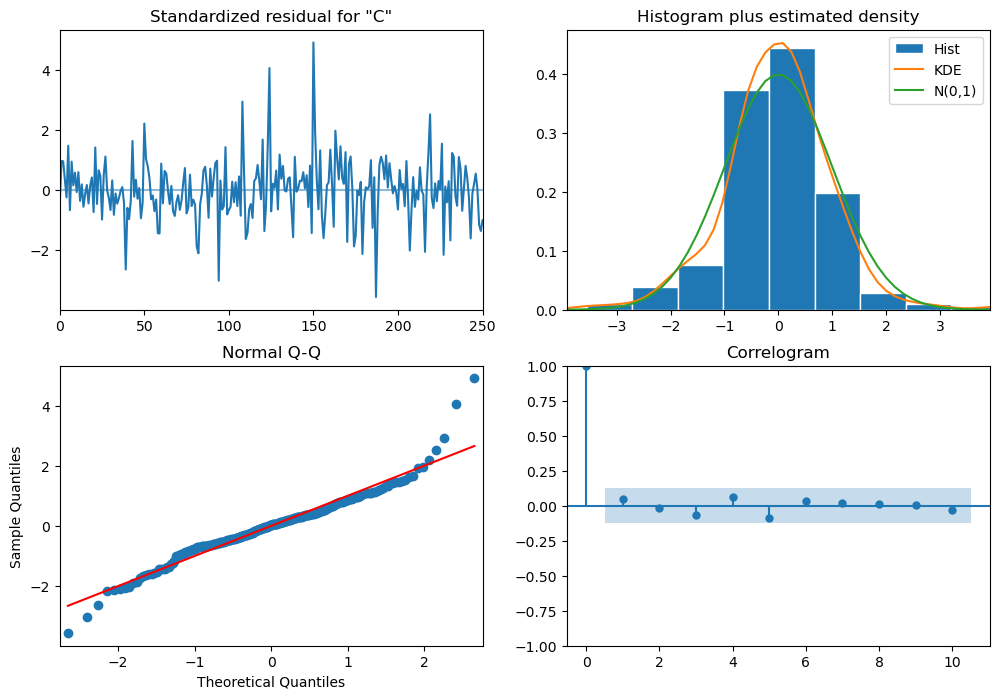

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       1.8944      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)       5.0064   0.4151  Sin autocorrelación


In [14]:
# Verificar ruido blanco
# Diagnóstico del modelo
def plot_diagnostics(modelo, n_lags=10):
    if not "statsmodels" in str(type(modelo)):
        raise TypeError("El objeto debe ser un modelo ajustado de statsmodels.")

    # Diagnóstico
    modelo.plot_diagnostics(figsize=(12, 8))
    plt.show()

    # test_autocorrelacion
    test_autocorrelacion(modelo.resid, n_lags=n_lags)

# Ejecución de la función
plot_diagnostics(modelo=mejor_modelo, n_lags=20)

- Independencia de Errores (Correlograma): El gráfico de autocorrelación muestra que todos los retardos (excepto el inicial) se mantienen dentro de la banda de confianza, lo que confirma que el modelo ha capturado la estructura temporal y los residuos son ruido blanco.

- Normalidad de Residuos (Histograma y Q-Q): Aunque la distribución (KDE) se asemeja a una campana de Gauss, el gráfico Q-Q muestra desviaciones en los extremos. Esto ratifica la presencia de "colas pesadas", donde los valores extremos ocurren con más frecuencia de lo normal.

- Homocedasticidad (Estandarizados): Los residuos estandarizados fluctúan mayormente entre -2 y 2 sin un patrón evidente de embudo, lo que sugiere que la varianza del error es relativamente estable, aunque con algunos picos de volatilidad aislados.

- Media Cero: La línea de tendencia en el gráfico de residuos estandarizados se sitúa sobre el eje central, validando que el modelo no presenta sesgos sistemáticos y que los errores promedio tienden a anularse.

- Ajuste del Modelo: La combinación de estas pruebas indica que, si bien el modelo es estadísticamente robusto para capturar la media, la naturaleza de los activos financieros (como Apple) introduce variaciones extremas que desafían la normalidad perfecta.

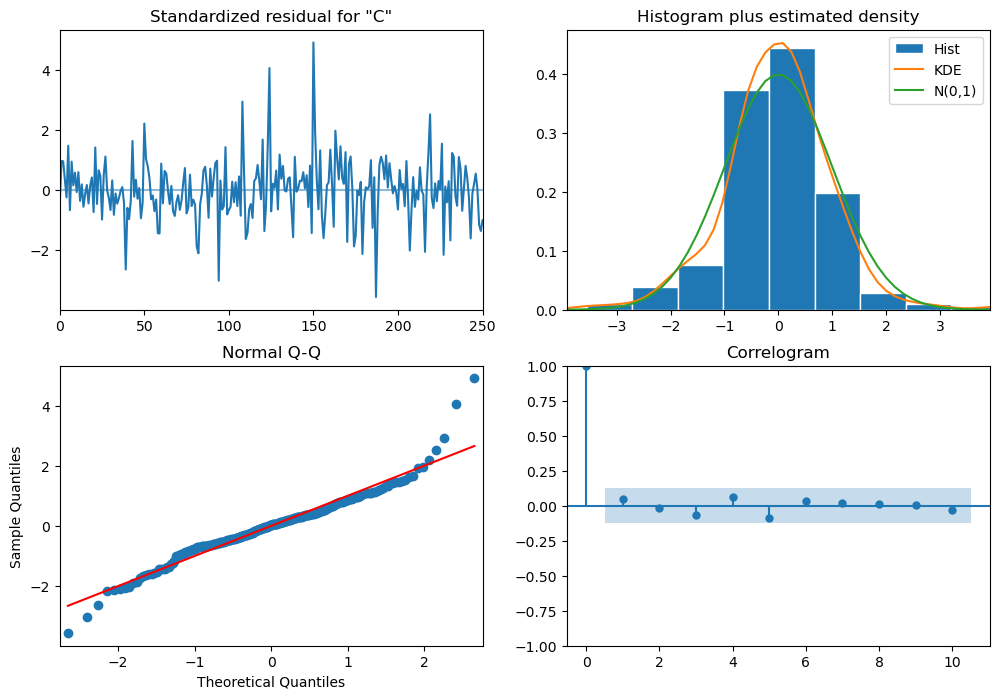

PRUEBA DE LJUNG-BOX Y DURBIN-WATSON
                       Test  Estadístico  P-valor           Conclusión
0             Durbin-Watson       1.8944      NaN  Sin autocorrelación
1  Ljung-Box (hasta lag 20)       5.0064   0.4151  Sin autocorrelación


In [15]:
# Verificar ruido blanco
plot_diagnostics(modelo=mejor_modelo, n_lags=20)

- Persistencia y Tendencia Inicial: La serie original de Apple mostró una tendencia alcista dominante y una memoria prolongada, evidenciada por un decaimiento lineal lento en la función de autocorrelación (ACF).

- Estacionariedad mediante Retornos: Al transformar los datos a retornos logarítmicos, se logró eliminar la tendencia, estabilizando la media cerca de cero y permitiendo un análisis estocástico válido.

- Agrupamiento de Volatilidad: Los retornos revelaron periodos de alta agitación concentrada, fenómeno conocido como volatility clustering, donde los movimientos extremos tienden a seguirse entre sí.

- Validación de Independencia: El diagnóstico de los residuos del modelo final confirmó que estos se comportan como ruido blanco, sin autocorrelaciones significativas pendientes por capturar.

- Desviación de la Normalidad: A pesar del buen ajuste, los residuos presentaron una distribución con "colas pesadas", indicando que los eventos de mercado extremos ocurren con mayor frecuencia de lo previsto por una distribución normal estándar.

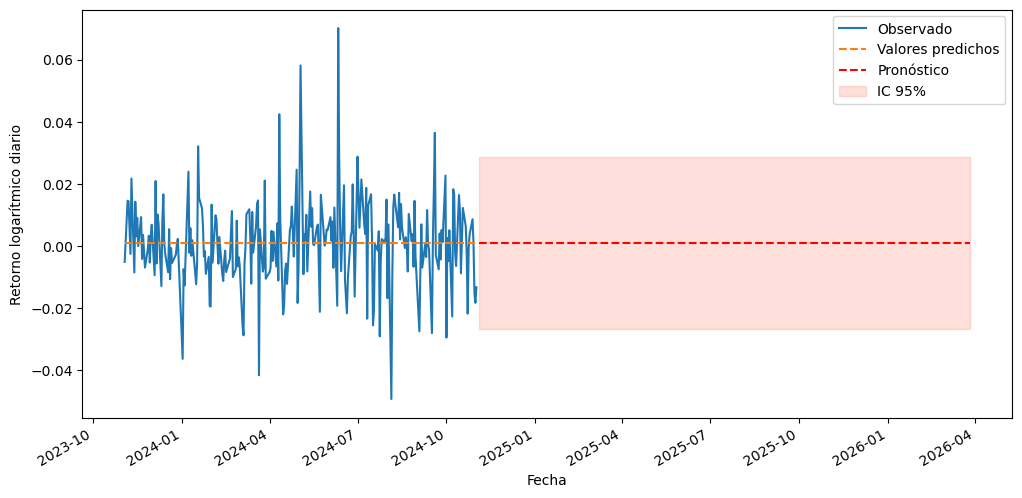

                           Pronóstico  IC Inferior  IC Superior
Fecha                                                          
2024-11-04 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-05 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-06 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-07 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-08 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-11 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-12 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-13 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-14 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-15 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-18 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-19 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-20 00:00:00+00:00    0.000901    -0.026798       0.0286
2024-11-21 00:00:00+00:00    0.000901   

In [16]:
# Pronóstico de los próximos 365 días hábiles (bursátiles)
t_pronostico    = 365
ultima_fecha    = apple_crecimiento.index[-1]
fechas_pronostico = pd.bdate_range(start=ultima_fecha + pd.Timedelta(days=1), periods=t_pronostico)

# Obtener valores promedio e intervalos del pronóstico
pronostico_apple = mejor_modelo.get_forecast(steps=t_pronostico)
pred_mean        = pronostico_apple.predicted_mean
pred_ci          = pronostico_apple.conf_int()

# Alinear índice con fechas bursátiles
pred_mean.index = fechas_pronostico
pred_ci.index   = fechas_pronostico

# Graficar resultados pronóstico
plt.figure(figsize=(12, 6))
ax = apple_crecimiento.plot(label="Observado")
plt.plot(mejor_modelo.fittedvalues.index, mejor_modelo.fittedvalues, label="Valores predichos", linestyle="--")
pred_mean.plot(ax=ax, label="Pronóstico", linestyle="--", color="red")
ax.fill_between(
    pred_ci.index,
    pred_ci.iloc[:, 0],
    pred_ci.iloc[:, 1],
    color='tomato', alpha=.2, label="IC 95%"
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Retorno logarítmico diario')
ax.legend()
plt.show()

# Tabla de pronóstico
df_forecast = pd.DataFrame({
    "Pronóstico"  : pred_mean,
    "IC Inferior" : pred_ci.iloc[:, 0],
    "IC Superior" : pred_ci.iloc[:, 1]
})
df_forecast.index.name = "Fecha"
print(df_forecast.to_string())

- Comportamiento y Estacionariedad: La serie de precios original mostró una tendencia alcista marcada y una fuerte dependencia temporal, confirmada por un decaimiento muy lento en la función de autocorrelación (ACF). Para corregir esto, se transformó la serie a retornos logarítmicos, logrando una media constante cercana a cero y eliminando la memoria persistente.

- Dinámica de Volatilidad: Al analizar los retornos, se identificó un claro agrupamiento de volatilidad (volatility clustering), donde los choques extremos se concentran en ventanas temporales específicas, como se observó a mediados de 2024.

- Validación del Proceso: Las gráficas de ACF y PACF de la serie diferenciada confirmaron que los datos se aproximan a un proceso de ruido blanco, ya que las correlaciones decayeron inmediatamente dentro de los intervalos de confianza.

- Calidad del Ajuste y Residuos: El diagnóstico de los residuos del modelo seleccionado ratificó su independencia; no obstante, la distribución de los errores mostró una naturaleza leptocúrtica (colas pesadas), indicando que el mercado de Apple es propenso a eventos extremos más frecuentes de lo que predice una distribución normal estándar.

- Capacidad Predictiva: El pronóstico generado se estabiliza rápidamente en el valor de la media de largo plazo, con intervalos de confianza que reflejan la incertidumbre inherente al activo. Esto sugiere que, tras extraer la estructura lineal, el movimiento diario restante es predominantemente aleatorio e impredecible en el corto plazo.

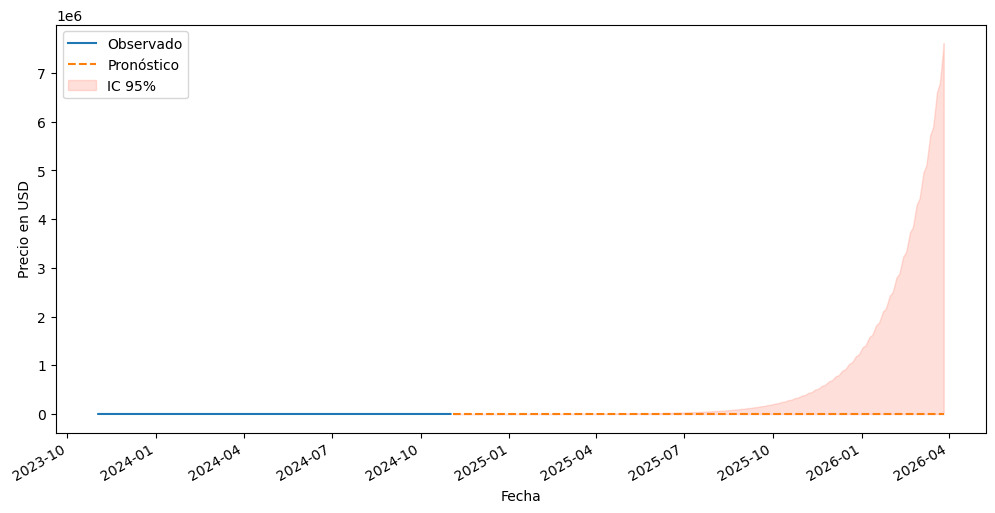

                           Pronóstico  IC Inferior   IC Superior
Fecha                                                           
2024-11-04 00:00:00+00:00  223.110915   217.015782  2.293772e+02
2024-11-05 00:00:00+00:00  223.312007   211.277416  2.360321e+02
2024-11-06 00:00:00+00:00  223.513280   205.690785  2.428800e+02
2024-11-07 00:00:00+00:00  223.714735   200.251877  2.499267e+02
2024-11-08 00:00:00+00:00  223.916371   194.956785  2.571777e+02
2024-11-11 00:00:00+00:00  224.118189   189.801707  2.646392e+02
2024-11-12 00:00:00+00:00  224.320189   184.782940  2.723171e+02
2024-11-13 00:00:00+00:00  224.522371   179.896880  2.802177e+02
2024-11-14 00:00:00+00:00  224.724736   175.140018  2.883476e+02
2024-11-15 00:00:00+00:00  224.927282   170.508938  2.967134e+02
2024-11-18 00:00:00+00:00  225.130011   166.000313  3.053218e+02
2024-11-19 00:00:00+00:00  225.332923   161.610907  3.141801e+02
2024-11-20 00:00:00+00:00  225.536018   157.337566  3.232953e+02
2024-11-21 00:00:00+00:00

In [17]:
# Revertir log-diferencia a niveles (precio)
ultimo_precio_nivel = apple_close.dropna().iloc[-1]

pred_niveles    = ultimo_precio_nivel * np.exp(pred_mean.cumsum())
pred_ci_niveles = pd.DataFrame({
    "lower": ultimo_precio_nivel * np.exp(pred_ci.iloc[:, 0].cumsum()),
    "upper": ultimo_precio_nivel * np.exp(pred_ci.iloc[:, 1].cumsum())
}, index=pred_mean.index)

# Graficar resultados pronóstico en niveles
plt.figure(figsize=(12, 6))
ax = apple_close.plot(label="Observado")
pred_niveles.plot(ax=ax, label="Pronóstico", linestyle="--")
ax.fill_between(
    pred_ci_niveles.index,
    pred_ci_niveles["lower"],
    pred_ci_niveles["upper"],
    color="tomato", alpha=0.2, label="IC 95%"
)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio en USD')
ax.legend()
plt.show()

# Tabla de pronóstico en niveles
df_forecast = pd.DataFrame({
    "Pronóstico"  : pred_niveles,
    "IC Inferior" : pred_ci_niveles["lower"],
    "IC Superior" : pred_ci_niveles["upper"],
})
df_forecast.index.name = "Fecha"
print(df_forecast.to_string())

- **Serie observada:** Los valores históricos del precio se mantienen en una escala significativamente menor en comparación con el pronóstico, lo que sugiere una posible discrepancia en la transformación o escalamiento de los datos utilizados en el modelo.

- **Comportamiento del pronóstico:** La proyección muestra un crecimiento explosivo y poco realista hacia el futuro, indicando que el modelo podría estar mal especificado o que la serie no fue correctamente estacionarizada antes de su estimación.

- **Intervalo de confianza (IC 95%):** La amplitud del intervalo aumenta de manera exponencial conforme avanza el horizonte de pronóstico, reflejando una elevada incertidumbre y una baja precisión predictiva del modelo.

- **Posible sobre-diferenciación:** El comportamiento divergente del pronóstico puede ser consecuencia de un exceso de diferenciación en el modelo ARIMA, lo que genera trayectorias inestables y no representativas de la dinámica real de la serie.

- **Escala de los datos:** La presencia del indicador `1e6` en el eje vertical sugiere que los valores están expresados en millones, lo que podría estar ocultando la verdadera variabilidad de la serie histórica y dificultando la interpretación visual.

- **Ausencia de coherencia con la dinámica histórica:** El pronóstico no guarda relación con la tendencia ni con la volatilidad observada en los datos históricos, lo que evidencia una falta de capacidad del modelo para capturar la estructura subyacente de la serie temporal.

- **Horizonte de pronóstico excesivo:** La extensión del pronóstico hasta un periodo lejano incrementa la incertidumbre y contribuye a la expansión del intervalo de confianza, reduciendo la utilidad práctica de las predicciones.

- **Recomendación metodológica:** Se sugiere revisar la estacionariedad de la serie (ADF/KPSS), verificar la aplicación correcta de transformaciones como el logaritmo, y reconsiderar la especificación del modelo (posiblemente incluyendo componentes estacionales mediante SARIMA o evaluando modelos alternativos).